# 🤖 **Model Benchmark — Bitcoin (BTC)**

### 🎯 **Objective**  
Evaluate and compare multiple machine learning models to predict **bearish reversals (crashes)** in Bitcoin.

### ⚠️ **Problem Definition**  
Binary classification task:

- `1` → Crash (>10% drop within 7 days)  
- `0` → No crash  

The dataset is **highly imbalanced** (~2% crashes), making this a **rare event prediction problem** in a **time series context**.

### 🔬 **Benchmark Focus**

1. **Baseline comparison**  
   - DummyClassifier (majority class)  
   - Logistic Regression (with class_weight)

2. **Model comparison (adapted to tabular time series + imbalance)**  
   - **Tree-based models (robust reference models)**
     - Random Forest (class_weight="balanced")
  
   - **Boosting methods (state-of-the-art on tabular data)**
     - XGBoost (scale_pos_weight)  
     - LightGBM (is_unbalance / scale_pos_weight)  
     - CatBoost (handles imbalance well, less tuning)
  
   - **Linear models (reference)**
     - Logistic Regression (regularized)

3. **Handling class imbalance**  
   - Class weights (balanced / scale_pos_weight)  
   - Threshold tuning (important for recall)  

4. **Evaluation metrics (critical)**  
   - Recall (detect crashes)  
   - Precision (avoid false alarms)  
   - F1-score  
   - **PR-AUC (main metric for rare events)**  

5. **Model ranking**  
   - Compare models based on PR-AUC and Recall  
   - Analyze trade-off Precision vs Recall  

### 🧪 **Benchmark Methodology**

The benchmark is conducted using a **time-aware cross-validation strategy** to ensure realistic evaluation and avoid data leakage.

- The dataset is first split into **Train / Test** using chronological order  
- All model comparisons are performed **exclusively on the Train set**  
- A **TimeSeriesSplit (cross-validation)** is applied:
  - Models are trained on past data and validated on future data  
  - This process is repeated across multiple folds  
- For each model:
  - Training and prediction are performed on each fold  
  - Metrics (PR-AUC, F1, Recall) are computed per fold  
  - Final performance is obtained by **averaging across folds**  

This approach provides a **robust and realistic estimate** of model performance under temporal constraints.

### 🧠 **Rationale for Model Selection**

The selected models are chosen to cover a spectrum of complexity and performance levels, while being well-suited for **tabular financial data and imbalanced classification**:

- **DummyClassifier**  
  Provides a minimal baseline to verify that models outperform trivial predictions  

- **Logistic Regression**  
  A simple and interpretable linear model that serves as a strong baseline for detecting linear relationships  

- **Random Forest**  
  A robust ensemble model that captures non-linear patterns and interactions with minimal tuning  

- **Boosting methods (XGBoost, LightGBM, CatBoost)**  
  State-of-the-art models for tabular data:
  - Handle non-linearities and feature interactions effectively  
  - Perform well on imbalanced datasets via weighting mechanisms  
  - Often achieve the best performance in structured data problems  

These models allow assessing:
- Whether simple signals exist (linear models)  
- Whether more complex patterns improve prediction (tree/boosting models)  
- The overall **predictability of crash events** in the dataset  

### 📏 **Rationale for Evaluation Metrics**

Standard metrics such as accuracy are **not suitable** in this context due to strong class imbalance (~2% crashes). A model predicting only the majority class would achieve high accuracy while being useless.

The selected metrics focus on the ability to detect rare but critical events:

- **Recall**  
  Measures the proportion of actual crashes correctly detected.  
  This is crucial as missing a crash is more costly than raising a false alarm.

- **Precision**  
  Measures how many predicted crashes are actually correct.  
  Important to avoid excessive false positives in practical usage.

- **F1-score**  
  Harmonic mean of Precision and Recall.  
  Provides a balanced view when both false positives and false negatives matter.

- **PR-AUC (Precision-Recall AUC)**  
  The most relevant metric for rare event detection:
  - Focuses on the minority class (crashes)  
  - Captures model performance across all classification thresholds  
  - More informative than ROC-AUC in highly imbalanced settings  

A random or trivial model yields a PR-AUC close to the positive class proportion (~2%), making it a strong baseline reference.

### 🚀 **Goal**  
Determine whether the dataset contains **predictive signal**, and identify the **best candidate models** (likely boosting methods) for the next steps: feature engineering, hyperparameter tuning, and time-aware validation.

In [3]:
import pandas as pd
from pipelines.ml_benchmark import run_benchmark_pipeline

### **1. View and clean DF**

In [4]:
# Load the dataset
df = pd.read_csv("../data/gold/market/btc_usdt_1d_features.csv")
df.head()

,open_time,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,...,lag_volume_norm,lag_buy_pressure,momentum_acc,volatility_ratio,momentum_volatility,pressure_x_return,ma_7,ma_30,ma_ratio,target
0,2017-09-16,3674.01,3950.00,3470.66,3714.95,1297.563953,4.804878e+06,8809,624.887842,2.314536e+06,...,2.390714,0.490700,-0.156191,1.727747,-0.013297,0.001946,3864.460000,4239.663667,0.911502,False
1,2017-09-17,3685.23,3748.21,3499.02,3699.99,682.171210,2.466490e+06,6355,273.931976,9.948436e+05,...,1.544177,0.481585,-0.008068,1.737193,-0.010831,-0.001617,3802.977143,4226.051000,0.899889,False
2,2017-09-18,3690.00,4123.20,3690.00,4035.01,1030.006455,4.069033e+06,8220,417.638722,1.651863e+06,...,0.828846,0.401559,0.094573,1.780640,-0.004561,0.036714,3778.197143,4222.552000,0.894766,True
3,2017-09-19,4060.00,4089.97,3830.91,3910.04,902.332129,3.558315e+06,7342,257.320352,1.016804e+06,...,1.219432,0.405472,-0.121518,1.783364,-0.006777,-0.008832,3741.957143,4216.677000,0.887418,False
4,2017-09-20,3910.04,4046.08,3820.00,3900.00,720.935076,2.839584e+06,7231,395.275138,1.562210e+06,...,1.050238,0.285173,0.028404,1.752188,-0.001237,-0.001408,3735.572857,4212.810333,0.886718,False


Delete useless columns (selected based on collinearity analysis in 01_eda_btc.ipynb)

In [5]:
SELECTED_FEATURES = [
    # Momentum
    "return_1d", "return_7d",

    # Volatility
    "volatility_7d", "volatility_30d",

    # Market behavior
    "buy_pressure",

    # Risk
    "drawdown",

    # Trend
    "ma_ratio",

    # Lags
    "lag_return_1d", "lag_return_7d",
    "lag_volatility_7d",
    "lag_buy_pressure",
    "lag_volume_norm",

    # Additional
    "momentum_acc",
    "momentum_volatility",
    "volume",
    "number_of_trades",
    "quote_asset_volume"
]

TARGET = "target"

df = df[SELECTED_FEATURES + [TARGET]]
df.head()

,return_1d,return_7d,volatility_7d,volatility_30d,buy_pressure,drawdown,ma_ratio,lag_return_1d,lag_return_7d,lag_volatility_7d,lag_buy_pressure,lag_volume_norm,momentum_acc,momentum_volatility,volume,number_of_trades,quote_asset_volume,target
0,0.004041,-0.127702,0.104128,0.060268,0.481585,-0.231640,0.911502,0.160231,-0.136079,0.103904,0.490700,2.390714,-0.156191,-0.013297,1297.563953,8809,4.804878e+06,False
1,-0.004027,-0.104199,0.103943,0.059834,0.401559,-0.234734,0.899889,0.004041,-0.127702,0.104128,0.481585,1.544177,-0.008068,-0.010831,682.171210,6355,2.466490e+06,False
2,0.090546,-0.041217,0.110665,0.062149,0.405472,-0.165443,0.894766,-0.004027,-0.104199,0.103943,0.401559,0.828846,0.094573,-0.004561,1030.006455,8220,4.069033e+06,True
3,-0.030971,-0.060926,0.111239,0.062376,0.285173,-0.191290,0.887418,0.090546,-0.041217,0.110665,0.405472,1.219432,-0.121518,-0.006777,902.332129,7342,3.558315e+06,False
4,-0.002568,-0.011329,0.109144,0.062290,0.548281,-0.193367,0.886718,-0.030971,-0.060926,0.111239,0.285173,1.050238,0.028404,-0.001237,720.935076,7231,2.839584e+06,False


Handle NaN values

In [6]:
df.isna().sum()

return_1d              0
return_7d              0
volatility_7d          0
volatility_30d         0
buy_pressure           0
drawdown               0
ma_ratio               0
lag_return_1d          0
lag_return_7d          0
lag_volatility_7d      0
lag_buy_pressure       0
lag_volume_norm        0
momentum_acc           0
momentum_volatility    0
volume                 0
number_of_trades       0
quote_asset_volume     0
target                 0
dtype: int64

No NaN value in the df

Setup X,y train and test

In [7]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
X_train.shape

(2489, 17)

Setup

[I 2026-03-26 16:51:20,067] A new study created in memory with name: no-name-4eda8f60-524c-4bfd-af96-f3a9790da266
[I 2026-03-26 16:51:20,093] Trial 0 finished with value: 0.024154589371980676 and parameters: {}. Best is trial 0 with value: 0.024154589371980676.
[I 2026-03-26 16:51:20,119] Trial 1 finished with value: 0.024154589371980676 and parameters: {}. Best is trial 0 with value: 0.024154589371980676.
[I 2026-03-26 16:51:20,148] Trial 2 finished with value: 0.024154589371980676 and parameters: {}. Best is trial 0 with value: 0.024154589371980676.
[I 2026-03-26 16:51:20,171] Trial 3 finished with value: 0.024154589371980676 and parameters: {}. Best is trial 0 with value: 0.024154589371980676.
[I 2026-03-26 16:51:20,185] Trial 4 finished with value: 0.024154589371980676 and parameters: {}. Best is trial 0 with value: 0.024154589371980676.
[I 2026-03-26 16:51:20,204] Trial 5 finished with value: 0.024154589371980676 and parameters: {}. Best is trial 0 with value: 0.024154589371980676


MODEL: dummy


[I 2026-03-26 16:51:20,279] Trial 10 finished with value: 0.024154589371980676 and parameters: {}. Best is trial 0 with value: 0.024154589371980676.
[I 2026-03-26 16:51:20,291] Trial 11 finished with value: 0.024154589371980676 and parameters: {}. Best is trial 0 with value: 0.024154589371980676.
[I 2026-03-26 16:51:20,303] Trial 12 finished with value: 0.024154589371980676 and parameters: {}. Best is trial 0 with value: 0.024154589371980676.
[I 2026-03-26 16:51:20,316] Trial 13 finished with value: 0.024154589371980676 and parameters: {}. Best is trial 0 with value: 0.024154589371980676.
[I 2026-03-26 16:51:20,330] Trial 14 finished with value: 0.024154589371980676 and parameters: {}. Best is trial 0 with value: 0.024154589371980676.
[I 2026-03-26 16:51:20,345] Trial 15 finished with value: 0.024154589371980676 and parameters: {}. Best is trial 0 with value: 0.024154589371980676.
[I 2026-03-26 16:51:20,359] Trial 16 finished with value: 0.024154589371980676 and parameters: {}. Best is


=== OPTUNA RESULTS ===
Best trial: 0
Best score (PR-AUC): 0.024154589371980676
Best params: {}

=== Best Threshold === 0.0347

=== Metrics ===
{'precision': 0.025362318840579712, 'recall': 0.42, 'f1': 0.04783599088838269, 'TP': 21.0, 'FP': 807.0, 'FN': 29.0, 'TN': 1213.0, 'pr_auc': 0.025933977455716583}

=== Global Confusion Matrix ===


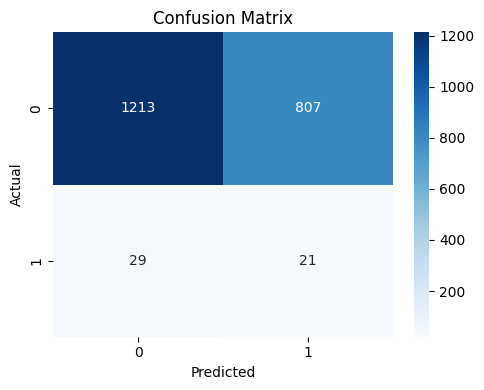

[I 2026-03-26 16:51:21,766] A new study created in memory with name: no-name-2745ce9d-0fe4-4594-bb20-0944aa77e618
/home/pierre/Documents/Documents/crypto/crypto-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/pierre/Documents/Documents/crypto/crypto-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/pierre/Documents/Documents/crypto/crypto-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in 


MODEL: logistic


/home/pierre/Documents/Documents/crypto/crypto-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/pierre/Documents/Documents/crypto/crypto-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/pierre/Documents/Documents/crypto/crypto-prediction/.venv/lib/python3.12/site-packages/sklearn/linea


=== OPTUNA RESULTS ===
Best trial: 77
Best score (PR-AUC): 0.1330982158346506
Best params: {'penalty': 'l1', 'solver': 'liblinear', 'C': 0.3968820557850234}


/home/pierre/Documents/Documents/crypto/crypto-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/pierre/Documents/Documents/crypto/crypto-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/pierre/Documents/Documents/crypto/crypto-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use '


=== Best Threshold === 0.4456

=== Metrics ===
{'precision': 0.06109324758842444, 'recall': 0.76, 'f1': 0.1130952380952381, 'TP': 38.0, 'FP': 584.0, 'FN': 12.0, 'TN': 1436.0, 'pr_auc': 0.0725111436925481}

=== Global Confusion Matrix ===


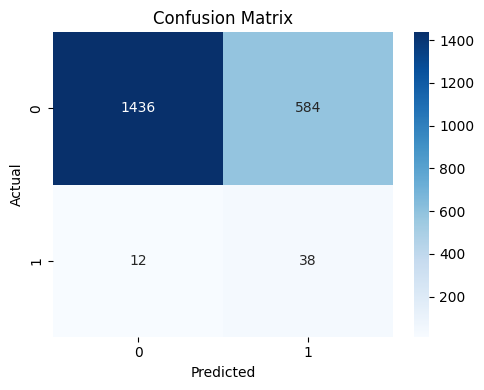

[I 2026-03-26 16:51:42,997] A new study created in memory with name: no-name-33640380-1cea-4017-ae65-3a1600911a6a



MODEL: random_forest


[I 2026-03-26 16:51:49,397] Trial 0 finished with value: 0.13574428614663298 and parameters: {'n_estimators': 666, 'max_depth': 12, 'min_samples_leaf': 18, 'min_samples_split': 7, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 0.13574428614663298.
[I 2026-03-26 16:51:55,219] Trial 1 finished with value: 0.13743018295836057 and parameters: {'n_estimators': 583, 'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 20, 'max_features': 0.5, 'bootstrap': False}. Best is trial 1 with value: 0.13743018295836057.
[I 2026-03-26 16:52:00,680] Trial 2 finished with value: 0.14300480623217215 and parameters: {'n_estimators': 583, 'max_depth': 10, 'min_samples_leaf': 11, 'min_samples_split': 8, 'max_features': 'log2', 'bootstrap': False}. Best is trial 2 with value: 0.14300480623217215.
[I 2026-03-26 16:52:08,007] Trial 3 finished with value: 0.17422065240370843 and parameters: {'n_estimators': 780, 'max_depth': 9, 'min_samples_leaf': 1, 'min_samples_split': 2, 'ma


=== OPTUNA RESULTS ===
Best trial: 3
Best score (PR-AUC): 0.17422065240370843
Best params: {'n_estimators': 780, 'max_depth': 9, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': 'log2', 'bootstrap': False}

=== Best Threshold === 0.4307

=== Metrics ===
{'precision': 0.11428571428571428, 'recall': 0.24, 'f1': 0.15483870967741936, 'TP': 12.0, 'FP': 93.0, 'FN': 38.0, 'TN': 1927.0, 'pr_auc': 0.08454805180881785}

=== Global Confusion Matrix ===


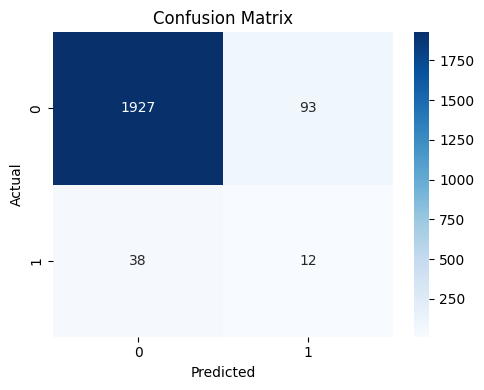

=== Model Benchmarking Results ===


,precision,recall,f1,TP,FP,FN,TN,pr_auc
random_forest,0.114286,0.24,0.154839,12.0,93.0,38.0,1927.0,0.084548
logistic,0.061093,0.76,0.113095,38.0,584.0,12.0,1436.0,0.072511
dummy,0.025362,0.42,0.047836,21.0,807.0,29.0,1213.0,0.025934


In [8]:

results = run_benchmark_pipeline(df, verbose=True, plot_confusion=True)

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values("pr_auc", ascending=False)

print("=== Model Benchmarking Results ===")
results_df